In [1]:
library(ape)
library(ggtree)
library(ggplot2)
library(patchwork)
# set input and output paths

indir <- "../../results/coalescent_astral/astral4_nt"
outdir <- file.path(indir, "tree_plots")
dir.create(outdir, recursive = TRUE, showWarnings = FALSE)

# color tips by biological lineage / comparison group
lineage_df <- data.frame(
    label = c("Bg", "Ee", "Bb", "Pk", "Ip"),
    lineage = c(
        "South American electric fishes",
        "South American electric fishes",
        "African weakly electric fishes",
        "African weakly electric fishes",
        "Ictaluridae outgroup"
    )
)

lineage_palette <- c(
    "South American electric fishes" = "#1b9e77",
    "African weakly electric fishes" = "#d95f02",
    "Ictaluridae outgroup" = "#7570b3"
)

lineage_shapes <- c(
    "South American electric fishes" = 21,
    "African weakly electric fishes" = 22,
    "Ictaluridae outgroup" = 24
)

ggtree v4.0.5 Learn more at https://yulab-smu.top/contribution-tree-data/

Please cite:

Guangchuang Yu, David Smith, Huachen Zhu, Yi Guan, Tommy Tsan-Yuk Lam.
ggtree: an R package for visualization and annotation of phylogenetic
trees with their covariates and other associated data. Methods in
Ecology and Evolution. 2017, 8(1):28-36. doi:10.1111/2041-210X.12628


Attaching package: ‘ggtree’


The following object is masked from ‘package:ape’:

    rotate




In [9]:
## function to root tree using outgroup and plot
plot_tree <- function(tree_file, outfile_prefix, plot_title) {

    tree <- read.tree(tree_file)

    # used -o Ip, but ape still reads the tree as unrooted.
    if (is.rooted(tree)) {
        cat("Tree is already rooted\n")
    } else {
        cat("Tree is unrooted, rooting with Ip as outgroup...\n")
        cat("Unrooted tree:")
        print(tree)
        tree <- root(tree, outgroup = "Ip", resolve.root = FALSE)
    }
    tree <- ladderize(tree)

    cat("Rooted tree - with Ip:
")
    print(tree)

    p <- ggtree(tree, layout = "rectangular", size = 0.9) %<+% lineage_df +
        geom_tippoint( aes(color = lineage, shape = lineage), size = 3, fill = "white", stroke = 1.1 ) +
        geom_tiplab( aes(color = lineage), size = 4, fontface = "bold", offset = 0.01, show.legend = FALSE ) +
        geom_label2( aes(subset = !isTip & !is.na(label) & label != "", label = label), hjust = -0.15, vjust = -0.35, size = 3, label.size = 0.2, fill = "white",  color = "gray25"  ) +
        scale_color_manual(values = lineage_palette, name = "Lineage / group") +
        scale_shape_manual(values = lineage_shapes, name = "Lineage / group") +
        ggtitle(plot_title) +
        theme_tree2() +
        theme( plot.title = element_text(hjust = 0.5, face = "bold", size = 14), legend.position = "right", legend.title = element_text(face = "bold") )

    pdf_file <- paste0(outfile_prefix, ".pdf")
    png_file <- paste0(outfile_prefix, ".png")

    ggsave(pdf_file, plot = p, width = 8, height = 5)
    ggsave(png_file, plot = p, width = 8, height = 5, dpi = 300)

    cat("
")
    return(p)
}

Tree is already rooted
Rooted tree - with Ip:

Phylogenetic tree with 5 tips and 4 internal nodes.

Tip labels:
  Ee, Bg, Bb, Pk, Ip
Node labels:
  , , 1, 1

Rooted; includes branch length(s).


Warning message in geom_label2(aes(subset = !isTip & !is.na(label) & label != "", :
“Ignoring unknown parameters: `label.size`”


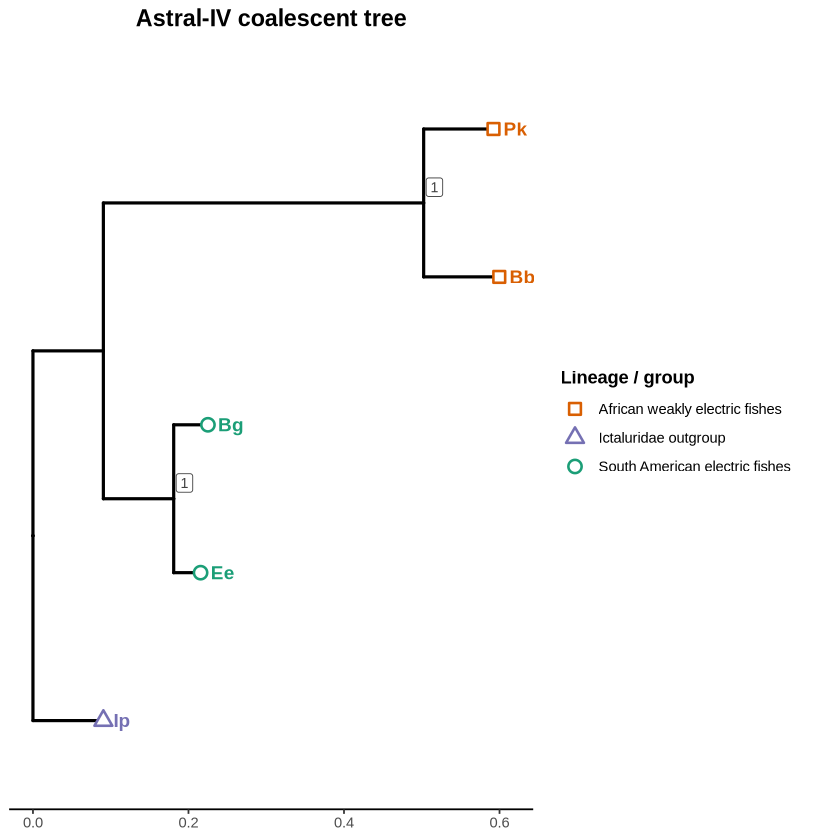

In [11]:
# plot tree
plot_tree(
	tree_file = file.path(indir, "astral4_species_tree_nt.tre"),
	outfile_prefix = file.path(outdir, "astral4_species_tree"),
	plot_title = "Astral-IV coalescent tree"
)